# Fine-Tuned ResNet18 for Guitar Type Classification

This notebook implements a **pretrained ResNet18** using **transfer learning**
for multi-class guitar image classification.

**Task:** Classify guitar images into 3 categories:
- Acoustic Guitar
- Electric Guitar
- Bass Guitar

**Approach:** Two-phase transfer learning:
1. **Phase 1** – Freeze backbone, train only the new classifier head
2. **Phase 2** – Unfreeze deeper layers and fine-tune end-to-end

**Comparison:** Results are compared against the baseline CNN and improved CNN.

## 1. Imports and Setup

In [2]:
import os
import copy
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## 2. Hyperparameters and Configuration

In [9]:
# ── Paths ──────────────────────────────────────────────────────────────
DATA_DIR = "dataset"
SAVE_PATH = "best_resnet18_model.pth"

# ── Image settings ─────────────────────────────────────────────────────
IMAGE_SIZE = 224

# ── Training settings ──────────────────────────────────────────────────
BATCH_SIZE = 32
PHASE1_EPOCHS = 20        # Frozen backbone – train classifier head only
PHASE2_EPOCHS = 20        # Unfrozen fine-tuning of full network
LEARNING_RATE = 0.0001    # Adam LR
NUM_CLASSES = 3

# ── Dataset split ratios ──────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# ── Reproducibility ───────────────────────────────────────────────────
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 3. Device Configuration

Automatically detect and use GPU (e.g. A100 on Google Colab).

In [4]:
def get_device():
    """Detect the best available device: CUDA GPU → CPU."""
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"[INFO] Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("[INFO] GPU not available, using CPU")
    return device

device = get_device()

[INFO] Using GPU: NVIDIA A100-SXM4-40GB


## 4. Data Loading and Preprocessing

**Training transforms** include data augmentation (random flips, rotation,
colour jitter, perspective) to improve generalisation.

**Validation/Test transforms** use only resize + normalize.

All images are normalised using ImageNet mean/std as required by pretrained models.

In [10]:
def get_transforms():
    """
    Return separate transforms for training (with augmentation)
    and evaluation (no augmentation).
    """
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
        transforms.RandomCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.2, hue=0.1),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    return train_transform, eval_transform


def load_and_split_data(train_transform, eval_transform):
    """
    Load dataset with ImageFolder and split into train/val/test.
    Training set uses augmentation transforms; val/test use plain transforms.
    """
    if not os.path.isdir(DATA_DIR):
        raise FileNotFoundError(
            f"[ERROR] '{DATA_DIR}' not found. "
            "Ensure the dataset directory exists."
        )

    # Load full dataset (we'll override transforms per split below)
    full_dataset = ImageFolder(root=DATA_DIR, transform=eval_transform)
    class_names  = full_dataset.classes
    n_total      = len(full_dataset)

    # Calculate split sizes
    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)
    n_test  = n_total - n_train - n_val

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )

    # Apply augmentation transforms only to training subset
    train_dataset.dataset = copy.copy(full_dataset)
    train_dataset.dataset.transform = train_transform

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )

    print(f"[INFO] Classes: {class_names}")
    print(f"[INFO] Total images : {n_total}")
    print(f"[INFO]   Train      : {n_train} ({TRAIN_RATIO*100:.0f}%)")
    print(f"[INFO]   Validation : {n_val} ({VAL_RATIO*100:.0f}%)")
    print(f"[INFO]   Test       : {n_test} ({TEST_RATIO*100:.0f}%)")

    return train_loader, val_loader, test_loader, class_names


# Load data
train_transform, eval_transform = get_transforms()
train_loader, val_loader, test_loader, class_names = load_and_split_data(
    train_transform, eval_transform
)

[INFO] Classes: ['acoustic', 'bass', 'electric']
[INFO] Total images : 4435
[INFO]   Train      : 3104 (70%)
[INFO]   Validation : 665 (15%)
[INFO]   Test       : 666 (15%)


## 5. ResNet18 Model with Transfer Learning

**Transfer learning steps:**
1. Load pretrained ResNet18 weights (ImageNet)
2. Freeze all backbone layers
3. Replace the final fully connected layer for 3-class output
4. Phase 1: Train only the classifier head
5. Phase 2: Unfreeze deeper layers (layer3, layer4) and fine-tune

In [11]:
def build_resnet18(num_classes, freeze_backbone=True):
    """
    Build a ResNet18 model with pretrained ImageNet weights.

    Args:
        num_classes: Number of output classes.
        freeze_backbone: If True, freeze all layers except the final FC.

    Returns:
        model: Modified ResNet18 model.
    """
    # Load pretrained ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze backbone layers if requested
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final fully connected layer
    # Original: Linear(512, 1000) → New: Linear(512, num_classes)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )

    return model


def unfreeze_deeper_layers(model):
    """
    Unfreeze layer3, layer4, and the classifier head for fine-tuning.
    Earlier layers (conv1, bn1, layer1, layer2) remain frozen to
    preserve low-level feature extractors learned from ImageNet.
    """
    # Unfreeze layer3 and layer4
    for name, param in model.named_parameters():
        if "layer3" in name or "layer4" in name or "fc" in name:
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"[INFO] Unfroze deeper layers. Trainable: {trainable:,} / {total:,}")


def print_model_summary(model):
    """Print model architecture and parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    frozen    = total - trainable
    print(f"\n[INFO] Total parameters     : {total:,}")
    print(f"[INFO] Trainable parameters : {trainable:,}")
    print(f"[INFO] Frozen parameters    : {frozen:,}")


# Build model
model = build_resnet18(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)
print(model)
print_model_summary(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 6. Training and Validation Functions

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns loss, accuracy, predictions, and labels."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

## 7. Training Loop (Two-Phase)

**Phase 1:** Train only the classifier head (backbone frozen).
**Phase 2:** Unfreeze layer3 + layer4 and fine-tune with a lower LR.

In [13]:
def train_phase(model, train_loader, val_loader, criterion, optimizer,
                scheduler, device, num_epochs, phase_name, save_path,
                best_val_acc=0.0):
    """
    Train for a single phase. Returns model, history dict, and best val acc.
    """
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_weights = copy.deepcopy(model.state_dict())

    print(f"\n{'='*60}")
    print(f"  {phase_name} — {num_epochs} epochs")
    print(f"{'='*60}\n")

    for epoch in range(1, num_epochs + 1):
        t_start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - t_start
        print(
            f"Epoch [{epoch:>2}/{num_epochs}]  "
            f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  |  "
            f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%  |  "
            f"Time: {elapsed:.1f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            print(f"  → Best model saved (val_acc: {best_val_acc*100:.2f}%)")

    model.load_state_dict(best_weights)
    print(f"\n  {phase_name} complete. Best val acc: {best_val_acc*100:.2f}%")
    return model, history, best_val_acc


# ── Phase 1: Train classifier head only ───────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)
scheduler_p1 = StepLR(optimizer_p1, step_size=5, gamma=0.5)

model, history_p1, best_val_acc = train_phase(
    model, train_loader, val_loader, criterion, optimizer_p1,
    scheduler_p1, device, PHASE1_EPOCHS,
    "Phase 1: Classifier Head Training", SAVE_PATH
)

# ── Phase 2: Fine-tune deeper layers ──────────────────────────────────
unfreeze_deeper_layers(model)
print_model_summary(model)

optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE * 0.5   # Lower LR for fine-tuning
)
scheduler_p2 = StepLR(optimizer_p2, step_size=5, gamma=0.5)

model, history_p2, best_val_acc = train_phase(
    model, train_loader, val_loader, criterion, optimizer_p2,
    scheduler_p2, device, PHASE2_EPOCHS,
    "Phase 2: Fine-Tuning (layer3 + layer4)", SAVE_PATH,
    best_val_acc=best_val_acc
)

# Merge histories
history = {
    k: history_p1[k] + history_p2[k] for k in history_p1
}


  Phase 1: Classifier Head Training — 20 epochs

Epoch [ 1/20]  Train Loss: 0.9889  Train Acc: 51.32%  |  Val Loss: 0.8510  Val Acc: 64.81%  |  Time: 12.1s
  → Best model saved (val_acc: 64.81%)
Epoch [ 2/20]  Train Loss: 0.8429  Train Acc: 61.79%  |  Val Loss: 0.7221  Val Acc: 70.83%  |  Time: 12.1s
  → Best model saved (val_acc: 70.83%)
Epoch [ 3/20]  Train Loss: 0.7737  Train Acc: 65.14%  |  Val Loss: 0.6592  Val Acc: 77.59%  |  Time: 12.3s
  → Best model saved (val_acc: 77.59%)
Epoch [ 4/20]  Train Loss: 0.7216  Train Acc: 68.56%  |  Val Loss: 0.6387  Val Acc: 76.54%  |  Time: 12.2s
Epoch [ 5/20]  Train Loss: 0.7021  Train Acc: 69.85%  |  Val Loss: 0.6226  Val Acc: 76.84%  |  Time: 12.5s
Epoch [ 6/20]  Train Loss: 0.6836  Train Acc: 71.17%  |  Val Loss: 0.6040  Val Acc: 77.74%  |  Time: 12.3s
  → Best model saved (val_acc: 77.74%)
Epoch [ 7/20]  Train Loss: 0.6739  Train Acc: 70.75%  |  Val Loss: 0.6014  Val Acc: 78.05%  |  Time: 12.4s
  → Best model saved (val_acc: 78.05%)
Epoch 

## 8. Training Curves

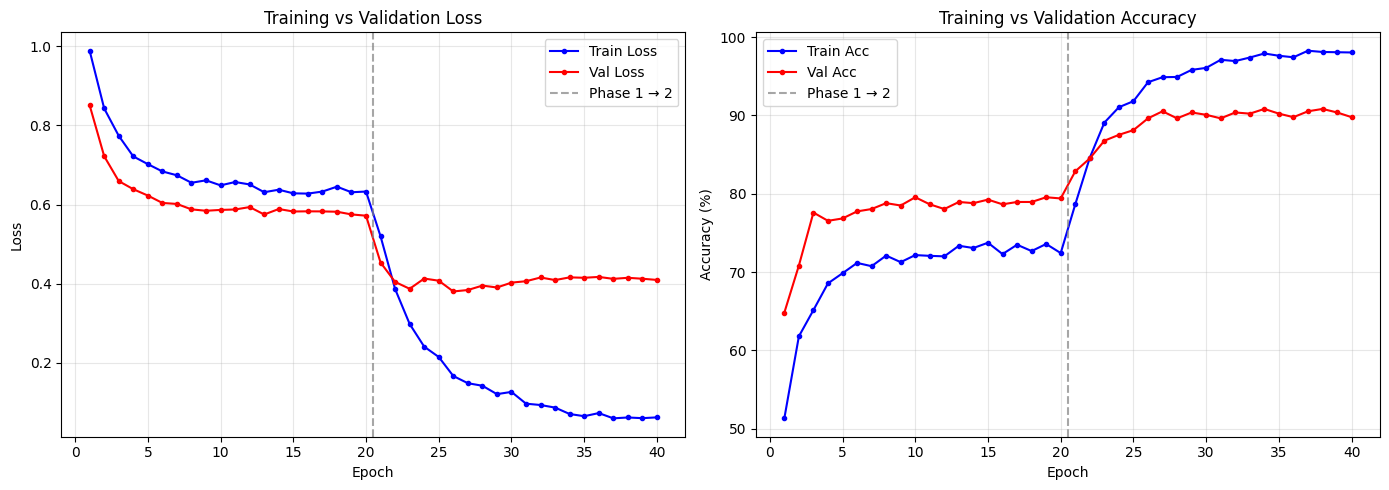

In [14]:
def plot_training_curves(history, phase1_epochs):
    """Plot loss and accuracy curves with a vertical line at the phase boundary."""
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss", markersize=3)
    ax1.plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss", markersize=3)
    ax1.axvline(x=phase1_epochs + 0.5, color="gray", linestyle="--",
                label="Phase 1 → 2", alpha=0.7)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training vs Validation Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs_range, [a*100 for a in history["train_acc"]], "b-o",
             label="Train Acc", markersize=3)
    ax2.plot(epochs_range, [a*100 for a in history["val_acc"]], "r-o",
             label="Val Acc", markersize=3)
    ax2.axvline(x=phase1_epochs + 0.5, color="gray", linestyle="--",
                label="Phase 1 → 2", alpha=0.7)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Training vs Validation Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history, PHASE1_EPOCHS)

## 9. Test Set Evaluation

In [15]:
def evaluate_on_test(model, test_loader, criterion, device, class_names):
    """Evaluate on test set and print classification report."""
    test_loss, test_acc, all_preds, all_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\n{'='*60}")
    print(f"  FINAL TEST RESULTS (Fine-Tuned ResNet18)")
    print(f"{'='*60}")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test Accuracy : {test_acc*100:.2f}%")
    print(f"{'='*60}\n")

    print("Classification Report:")
    print("-" * 60)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names, digits=4
    ))

    return test_acc, all_preds, all_labels


test_acc, all_preds, all_labels = evaluate_on_test(
    model, test_loader, criterion, device, class_names
)


  FINAL TEST RESULTS (Fine-Tuned ResNet18)
  Test Loss     : 0.3648
  Test Accuracy : 90.54%

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    acoustic     0.9207    0.9414    0.9310       222
        bass     0.8889    0.8972    0.8930       214
    electric     0.9058    0.8783    0.8918       230

    accuracy                         0.9054       666
   macro avg     0.9051    0.9056    0.9053       666
weighted avg     0.9053    0.9054    0.9053       666



## 10. Confusion Matrix

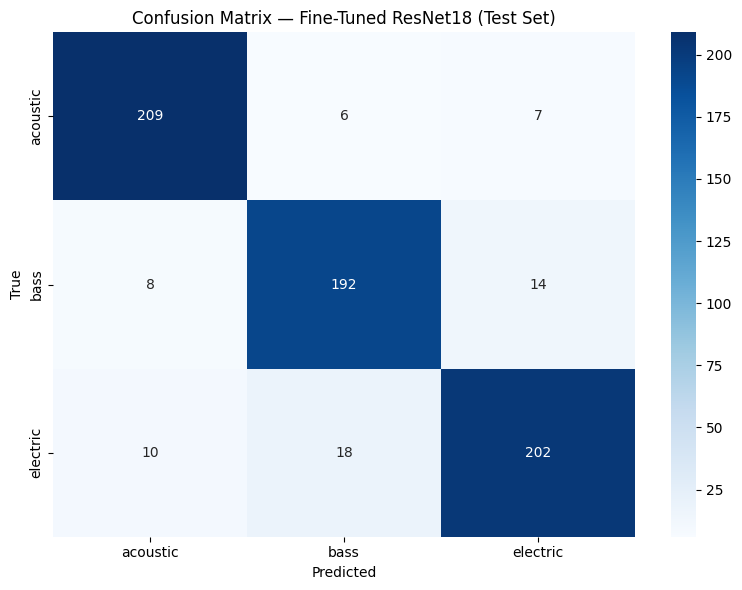

In [16]:
def plot_confusion_matrix(all_labels, all_preds, class_names):
    """Plot a heatmap confusion matrix."""
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix — Fine-Tuned ResNet18 (Test Set)")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(all_labels, all_preds, class_names)

## 11. Sample Predictions

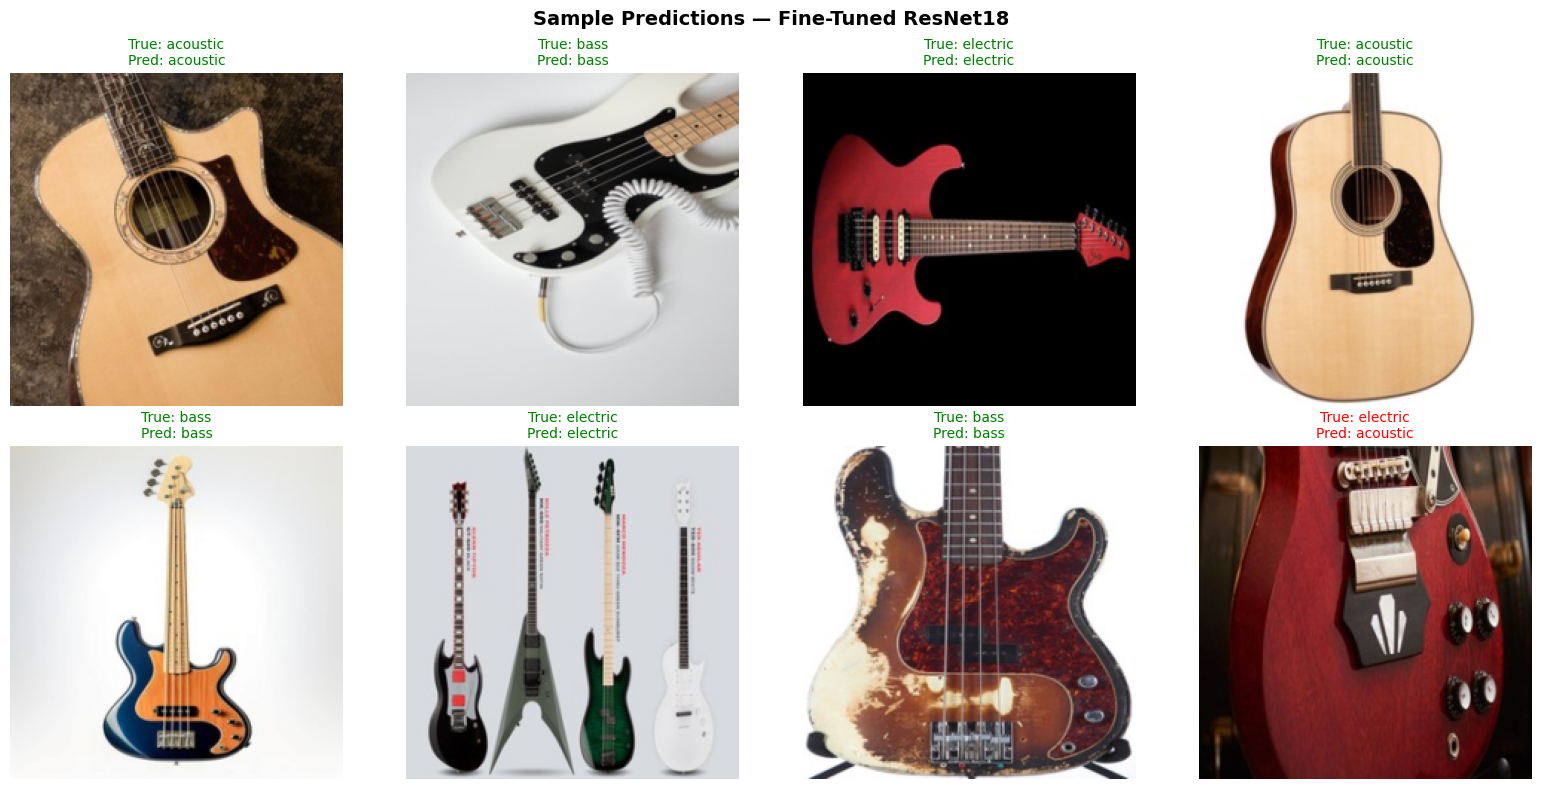

In [17]:
def show_sample_predictions(model, test_loader, class_names, device, num_samples=8):
    """Display sample predictions from the test set."""
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(num_samples):
        img = images[i].cpu() * std + mean
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]
        color = "green" if true_label == pred_label else "red"

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}",
                          color=color, fontsize=10)
        axes[i].axis("off")

    plt.suptitle("Sample Predictions — Fine-Tuned ResNet18",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_sample_predictions(model, test_loader, class_names, device)

## 12. Model Comparison — Baseline vs Improved vs ResNet18

Enter the results from the baseline and improved CNN notebooks to compare.

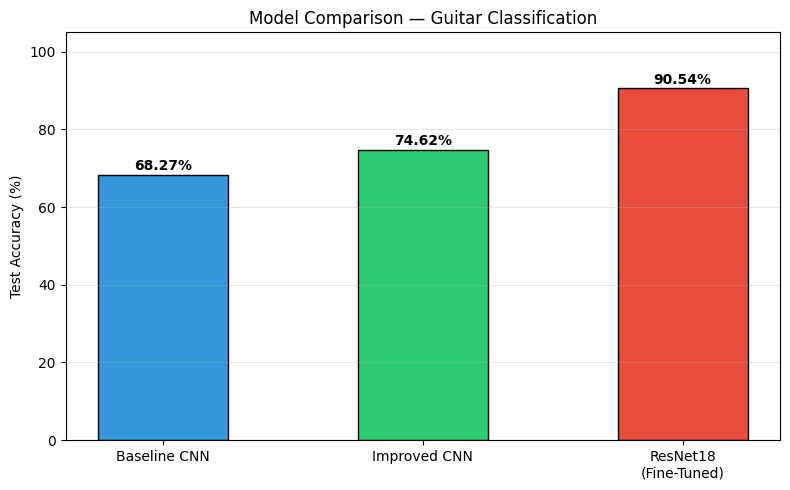

  MODEL COMPARISON SUMMARY
  Baseline CNN              : 68.27%
  Improved CNN              : 74.62%
  ResNet18 (Fine-Tuned)     : 90.54%


In [19]:
def compare_models():
    """
    Compare test accuracy across all three model architectures.
    Update baseline_acc and improved_acc with your actual results.
    """
    # ── Update these with your actual results ──────────────────────────
    baseline_acc = 0.6827 * 100
    improved_acc = 0.7462 * 100
    resnet18_acc = test_acc * 100

    model_names = ["Baseline CNN", "Improved CNN", "ResNet18\n(Fine-Tuned)"]
    accuracies  = [baseline_acc, improved_acc, resnet18_acc]
    colors      = ["#3498db", "#2ecc71", "#e74c3c"]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(model_names, accuracies, color=colors, edgecolor="black",
                  width=0.5)

    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold")

    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("Model Comparison — Guitar Classification")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

  
    print("  MODEL COMPARISON SUMMARY")

    for name, acc in zip(model_names, accuracies):
        print(f"  {name.replace(chr(10), ' '):<25} : {acc:.2f}%")



compare_models()

## 13. Deployment Preparation

Save the model in a format ready for real-time webcam classification
using OpenCV. This section exports the model along with class names
and preprocessing info.

In [20]:
def save_for_deployment(model, class_names, save_path="resnet18_deploy.pth"):
    """
    Save model weights along with metadata for deployment.
    The saved checkpoint can be loaded for OpenCV webcam inference.
    """
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "image_size": IMAGE_SIZE,
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
        "model_architecture": "resnet18",
        "num_classes": NUM_CLASSES,
    }
    torch.save(checkpoint, save_path)
    print(f"[INFO] Deployment checkpoint saved to '{save_path}'")
    print(f"[INFO] Contains: model weights, class names, preprocessing config")


save_for_deployment(model, class_names)

[INFO] Deployment checkpoint saved to 'resnet18_deploy.pth'
[INFO] Contains: model weights, class names, preprocessing config


## Summary

This notebook implements transfer learning with **pretrained ResNet18** for
guitar type classification using a two-phase training strategy:

**Phase 1 — Classifier Head Training:**
- Backbone frozen; only the new FC head is trained
- Leverages ImageNet features as powerful fixed feature extractors

**Phase 2 — Fine-Tuning:**
- Unfreezes layer3 and layer4 for domain adaptation
- Uses a reduced learning rate to avoid destroying pretrained features

**Key advantages over baseline/improved CNN:**
- Pretrained ImageNet features provide strong starting representations
- Data augmentation improves generalisation
- Two-phase training prevents catastrophic forgetting
- Deployment-ready checkpoint for OpenCV webcam classification